# Practical: Customer Purchase Propensity - Data Cleaning and Feature Engineering Pipeline

## Step 1: Project Planning & Problem Framing

### 1. Briefly write a short plan (2–3 bullet points) explaining:




1. What is Data Analysis?

- Data Analysis is the process of collecting, cleaning, organizing, and examining data to discover useful information and support decision-making.

- Steps of Data Analysis:
    1. Collect data
    2. Clean the data
    3. Explore the data
    4. Analyze the data
    5. Visualize the results
    6. Make decisions based on findings

2. Steps in a Data Science project.

- Steps:
    1. Define the business problem.
    2. Collect data from different sources.
    3. Clean and preprocess the data.
    4. Explore the data using statistics and visualization.
    5. Build machine learning models.
    6. Evaluate model performance.
    7. Deploy the model.
    8. Monitor and improve the model.

3. How to frame this dataset as a Machine Learning problem (binary classification).
 (Theory + short notes section)

- Framing a machine learning problem involves understanding the business context and translating it into a data-driven question.

- Steps:
    1. Identify the problem.
    2. Define the target variable.
    3. Select input features.
    4. Choose the ML type:
        - Classification
        - Regression
        - Clustering
    5. Collect and prepare data.
    6. Select an evaluation metric.
    7. Train and test the model.

- short notes:
    - Binary classification is a type of supervised learning where the target variable has two classes (e.g., purchase or no purchase).
    - The goal is to predict the probability of a customer making a purchase based on their features.





## Step 2: Data Import and Understanding

### Loading all datasets (CSV, JSON, SQL, API).

In [1]:
import pandas as pd
customer_df = pd.read_csv("customers.csv")
customer_df.head()

,customer_id,name,age,gender,city,income
0,101,Aarav,24,Male,Mumbai,45000
1,102,Diya,30,Female,Delhi,55000
2,103,Kabir,27,Male,Bangalore,48000
3,104,Meera,35,Female,Ahmedabad,60000
4,105,Vivaan,40,Male,Pune,75000


In [2]:
import json

transaction_df = pd.read_json("transactions.json")
print(transaction_df.head())

  transaction_id  customer_id product_id  amount payment_mode       date
0           T001          101       P001     499          UPI 2025-10-01
1           T002          103       P003    1299  Credit Card 2025-10-02
2           T003          104       P002     699   Debit Card 2025-10-03
3           T004          105       P005    1999          UPI 2025-10-05
4           T005          107       P004     899         Cash 2025-10-07


In [3]:
import sqlite3

conn = sqlite3.connect("products.db")
product_df = pd.read_sql_query("SELECT * FROM products", conn)
conn.close()

In [4]:
import requests
import pandas as pd

url = "https://dummyjson.com/users"

response = requests.get(url)

api_df = pd.DataFrame(response.json())

display(api_df.head())

,users,total,skip,limit
0,"{'id': 1, 'firstName': 'Emily', 'lastName': 'J...",208,0,30
1,"{'id': 2, 'firstName': 'Michael', 'lastName': ...",208,0,30
2,"{'id': 3, 'firstName': 'Sophia', 'lastName': '...",208,0,30
3,"{'id': 4, 'firstName': 'James', 'lastName': 'D...",208,0,30
4,"{'id': 5, 'firstName': 'Emma', 'lastName': 'Mi...",208,0,30


### Merge them using relevant keys (customer_id, product_id).

In [5]:
# Merge them using relevant keys (customer_id, product_id).
merged_df = pd.merge(customer_df,transaction_df,on="customer_id",how="inner")

merged_df = pd.merge(merged_df,product_df,on="product_id",how="inner")

display(merged_df)

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30
5,106,Riya,22,Female,Chennai,42000,T008,P001,499,Cash,2025-10-10,Earphones,Electronics,499,50
6,107,Aryan,29,Male,Kolkata,50000,T005,P004,899,Cash,2025-10-07,Keyboard,Computer,899,60
7,108,Isha,33,Female,Surat,58000,T006,P006,2599,UPI,2025-10-08,Power Bank,Mobile Accessories,2599,20


### Explore the combined dataset (use .info(), .describe(), .head()).

In [6]:
# Explore the combined dataset (use .info(), .describe(), .head()).
merged_df.info()
merged_df.describe()
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     8 non-null      int64         
 1   name            8 non-null      object        
 2   age             8 non-null      int64         
 3   gender          8 non-null      object        
 4   city            8 non-null      object        
 5   income          8 non-null      int64         
 6   transaction_id  8 non-null      object        
 7   product_id      8 non-null      object        
 8   amount          8 non-null      int64         
 9   payment_mode    8 non-null      object        
 10  date            8 non-null      datetime64[ns]
 11  product_name    8 non-null      object        
 12  category        8 non-null      object        
 13  price           8 non-null      int64         
 14  stock           8 non-null      int64         
dtypes: datetim

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


## Step 3: Exploratory Data Analysis (EDA)

### Perform EDA in three stages:

### Univariate Analysis

- Visualize the distribution of numerical columns using histograms.

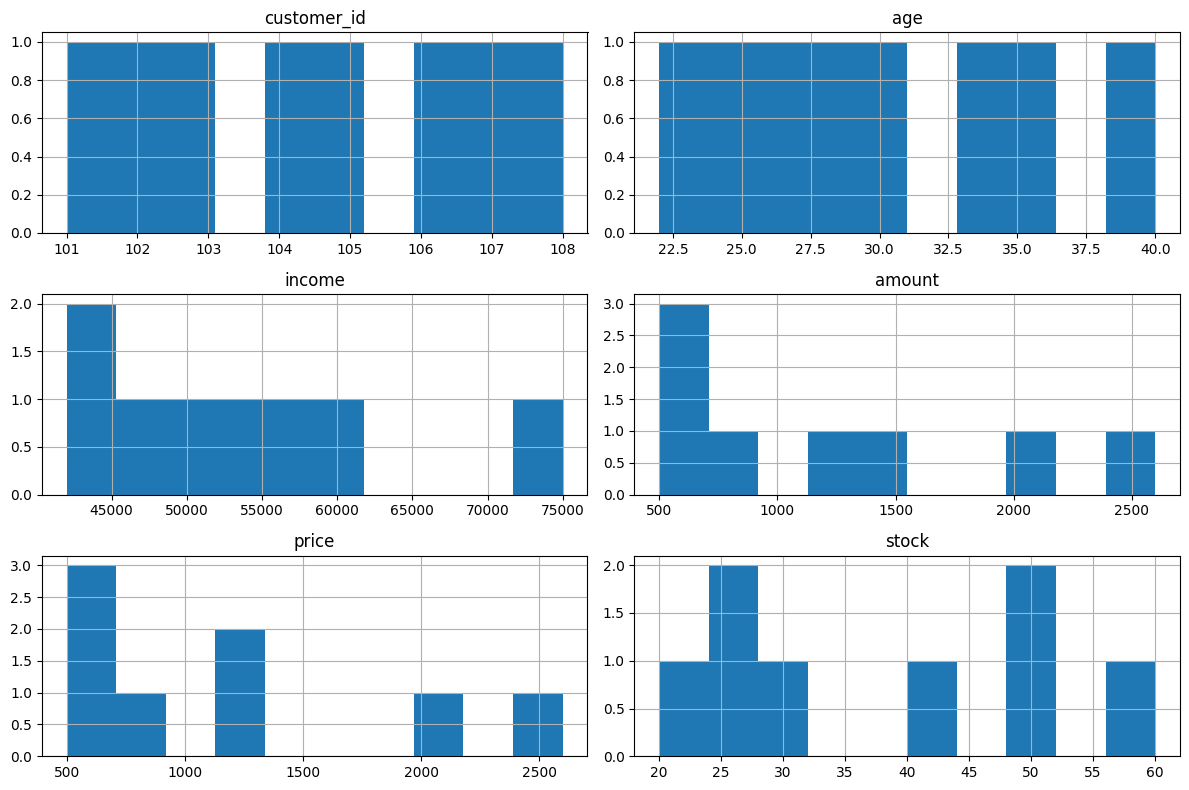

In [7]:
import matplotlib.pyplot as plt

numeric_cols = merged_df.select_dtypes(include='number').columns

merged_df[numeric_cols].hist(figsize=(12, 8), bins=10)

plt.tight_layout()
plt.show()

- Identify skewed variables.


In [8]:
skewness = merged_df.select_dtypes(include='number').skew()

print(skewness)

customer_id    0.000000
age            0.366520
income         1.073956
amount         0.813569
price          0.960237
stock          0.341565
dtype: float64


- Use Pandas Profiling for automated insights.

In [9]:

from ydata_profiling import ProfileReport

profile = ProfileReport(merged_df, title="Automated Data Analysis Report")

profile.to_file("data_profiling_report.html")

c:\Users\Divy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Divy\AppData\Local\Temp\ipykernel_10248\910065252.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 131.47it/s]


### Bivariate Analysis

- Correlate numerical features with the target column (purchased = 1 or 0).

In [10]:
numeric_df = merged_df.select_dtypes(include="number")

correlation = numeric_df.corr()

print(correlation)

             customer_id       age    income    amount     price     stock
customer_id     1.000000  0.237078  0.175063  0.408904  0.451160  0.059761
age             0.237078  1.000000  0.977640  0.624180  0.629314 -0.454561
income          0.175063  0.977640  1.000000  0.629398  0.631397 -0.467303
amount          0.408904  0.624180  0.629398  1.000000  0.995623 -0.787507
price           0.451160  0.629314  0.631397  0.995623  1.000000 -0.761444
stock           0.059761 -0.454561 -0.467303 -0.787507 -0.761444  1.000000


- Compare means and visualize relationships (e.g., Income vs Purchase).

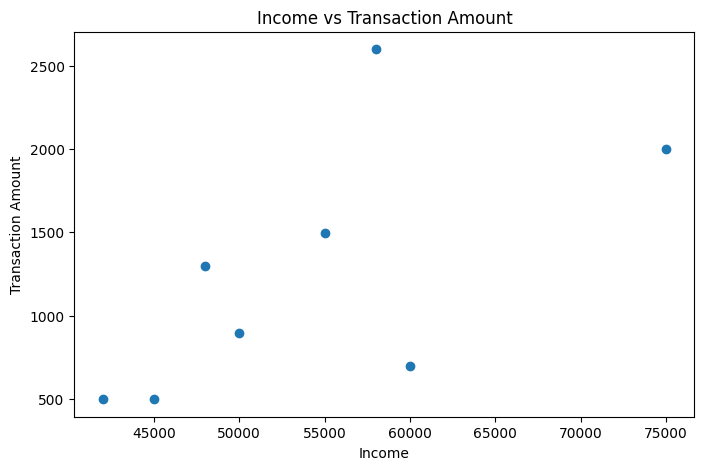

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(merged_df["income"],merged_df["amount"])

plt.title("Income vs Transaction Amount")
plt.xlabel("Income")
plt.ylabel("Transaction Amount")

plt.show()

### Multivariate Analysis

- Use pairplots, heatmaps, or grouped statistics to explore multiple feature relationships.

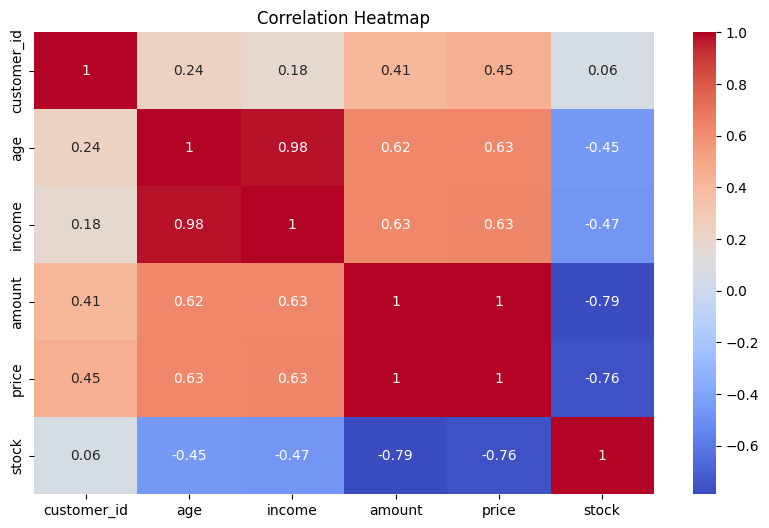

In [12]:
# 1. Heatmap — numerical relationships

import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = merged_df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

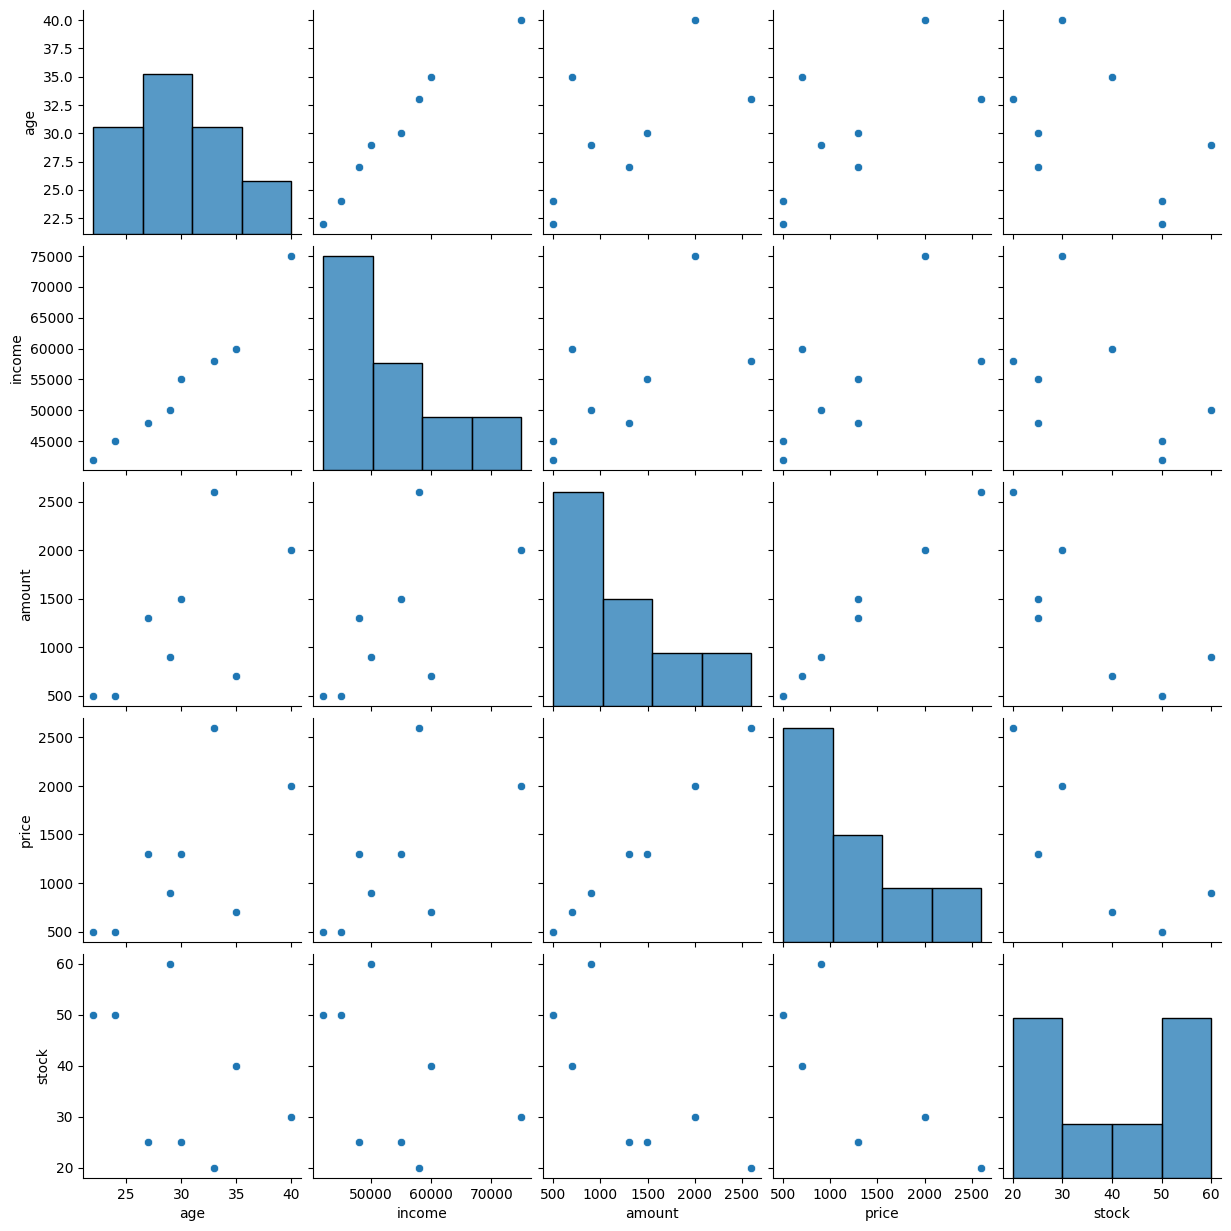

In [13]:
# 2. Pairplot — multiple relationships

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(merged_df[["age", "income", "amount", "price", "stock"]])

plt.show()

In [14]:
# 3. Grouped statistics

grouped_data = merged_df.groupby("category").agg({"income": "mean","amount": "mean","price": "mean"})

print(grouped_data)

                     income  amount   price
category                                   
Audio               67500.0  1349.0  1349.0
Computer            50000.0   899.0   899.0
Electronics         43500.0   499.0   499.0
Mobile Accessories  58000.0  2599.0  2599.0
Wearable            51500.0  1399.0  1299.0


## Step 4: Handling Missing Data

### Use different imputation techniques:

- Simple Imputer: for numerical and categorical missing values.

In [15]:
# Numerical columns

from sklearn.impute import SimpleImputer

num_cols = merged_df.select_dtypes(include="number").columns

num_imputer = SimpleImputer(strategy="median")

merged_df[num_cols] = num_imputer.fit_transform(merged_df[num_cols])
print(merged_df)


   customer_id    name   age  gender       city   income transaction_id  \
0        101.0   Aarav  24.0    Male     Mumbai  45000.0           T001   
1        102.0    Diya  30.0  Female      Delhi  55000.0           T007   
2        103.0   Kabir  27.0    Male  Bangalore  48000.0           T002   
3        104.0   Meera  35.0  Female  Ahmedabad  60000.0           T003   
4        105.0  Vivaan  40.0    Male       Pune  75000.0           T004   
5        106.0    Riya  22.0  Female    Chennai  42000.0           T008   
6        107.0   Aryan  29.0    Male    Kolkata  50000.0           T005   
7        108.0    Isha  33.0  Female      Surat  58000.0           T006   

  product_id  amount payment_mode       date       product_name  \
0       P001   499.0          UPI 2025-10-01          Earphones   
1       P003  1499.0  Credit Card 2025-10-09        Smart Watch   
2       P003  1299.0  Credit Card 2025-10-02        Smart Watch   
3       P002   699.0   Debit Card 2025-10-03  Bluetooth 

In [16]:
# Categorical columns
cat_cols = merged_df.select_dtypes(include="object").columns

cat_imputer = SimpleImputer(strategy="most_frequent")

merged_df[cat_cols] = cat_imputer.fit_transform(merged_df[cat_cols])

print(merged_df)

   customer_id    name   age  gender       city   income transaction_id  \
0        101.0   Aarav  24.0    Male     Mumbai  45000.0           T001   
1        102.0    Diya  30.0  Female      Delhi  55000.0           T007   
2        103.0   Kabir  27.0    Male  Bangalore  48000.0           T002   
3        104.0   Meera  35.0  Female  Ahmedabad  60000.0           T003   
4        105.0  Vivaan  40.0    Male       Pune  75000.0           T004   
5        106.0    Riya  22.0  Female    Chennai  42000.0           T008   
6        107.0   Aryan  29.0    Male    Kolkata  50000.0           T005   
7        108.0    Isha  33.0  Female      Surat  58000.0           T006   

  product_id  amount payment_mode       date       product_name  \
0       P001   499.0          UPI 2025-10-01          Earphones   
1       P003  1499.0  Credit Card 2025-10-09        Smart Watch   
2       P003  1299.0  Credit Card 2025-10-02        Smart Watch   
3       P002   699.0   Debit Card 2025-10-03  Bluetooth 

- Most Frequent Imputation: for mode-based filling.

In [17]:
# For both numerical and categorical columns

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

merged_df[:] = imputer.fit_transform(merged_df)

print(merged_df.isnull().sum())

customer_id       0
name              0
age               0
gender            0
city              0
income            0
transaction_id    0
product_id        0
amount            0
payment_mode      0
date              0
product_name      0
category          0
price             0
stock             0
dtype: int64


- Missing Indicator + Random Sample Imputation: show how missing flags are used.

In [18]:
import numpy as np

merged_df["income_missing"] = merged_df["income"].isnull().astype(int)

missing = merged_df["income"].isnull()

merged_df.loc[missing, "income"] = np.random.choice(merged_df.loc[~missing, "income"],size=missing.sum())

print(merged_df[["income", "income_missing"]].head(10))

    income  income_missing
0  45000.0               0
1  55000.0               0
2  48000.0               0
3  60000.0               0
4  75000.0               0
5  42000.0               0
6  50000.0               0
7  58000.0               0


- KNN Imputer: for multivariate imputation.

In [19]:
from sklearn.impute import KNNImputer

num_cols = merged_df.select_dtypes(include="number").columns

imputer = KNNImputer(n_neighbors=5)

merged_df[num_cols] = imputer.fit_transform(merged_df[num_cols])

print(merged_df[num_cols].isnull().sum())

customer_id       0
age               0
income            0
amount            0
price             0
stock             0
income_missing    0
dtype: int64


- MICE Algorithm: demonstrate chained imputation for correlated features.

In [20]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols = ["age", "income", "amount", "price", "stock"]

imputer = IterativeImputer(max_iter=10, random_state=42)

merged_df[cols] = imputer.fit_transform(merged_df[cols])

print(merged_df[cols].isnull().sum())

display(merged_df[cols].head())

age       0
income    0
amount    0
price     0
stock     0
dtype: int64


,age,income,amount,price,stock
0,24.0,45000.0,499.0,499.0,50.0
1,30.0,55000.0,1499.0,1299.0,25.0
2,27.0,48000.0,1299.0,1299.0,25.0
3,35.0,60000.0,699.0,699.0,40.0
4,40.0,75000.0,1999.0,1999.0,30.0


- Complete Case Analysis: drop missing rows as a comparison.

In [21]:

complete_df = merged_df.dropna()

display(complete_df)

print(complete_df.isnull().sum())

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock,income_missing
0,101.0,Aarav,24.0,Male,Mumbai,45000.0,T001,P001,499.0,UPI,2025-10-01,Earphones,Electronics,499.0,50.0,0.0
1,102.0,Diya,30.0,Female,Delhi,55000.0,T007,P003,1499.0,Credit Card,2025-10-09,Smart Watch,Wearable,1299.0,25.0,0.0
2,103.0,Kabir,27.0,Male,Bangalore,48000.0,T002,P003,1299.0,Credit Card,2025-10-02,Smart Watch,Wearable,1299.0,25.0,0.0
3,104.0,Meera,35.0,Female,Ahmedabad,60000.0,T003,P002,699.0,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699.0,40.0,0.0
4,105.0,Vivaan,40.0,Male,Pune,75000.0,T004,P005,1999.0,UPI,2025-10-05,Headphones,Audio,1999.0,30.0,0.0
5,106.0,Riya,22.0,Female,Chennai,42000.0,T008,P001,499.0,Cash,2025-10-10,Earphones,Electronics,499.0,50.0,0.0
6,107.0,Aryan,29.0,Male,Kolkata,50000.0,T005,P004,899.0,Cash,2025-10-07,Keyboard,Computer,899.0,60.0,0.0
7,108.0,Isha,33.0,Female,Surat,58000.0,T006,P006,2599.0,UPI,2025-10-08,Power Bank,Mobile Accessories,2599.0,20.0,0.0


customer_id       0
name              0
age               0
gender            0
city              0
income            0
transaction_id    0
product_id        0
amount            0
payment_mode      0
date              0
product_name      0
category          0
price             0
stock             0
income_missing    0
dtype: int64


## Step 5: Outlier Detection & Handling

### Apply at least 3 different techniques:

- Z-score Method

In [22]:
from scipy import stats

z_scores = stats.zscore(customer_df["income"])
Data = customer_df[abs(z_scores) < 3]
print("Z-score", customer_df.head())


Z-score    customer_id    name  age  gender       city  income
0          101   Aarav   24    Male     Mumbai   45000
1          102    Diya   30  Female      Delhi   55000
2          103   Kabir   27    Male  Bangalore   48000
3          104   Meera   35  Female  Ahmedabad   60000
4          105  Vivaan   40    Male       Pune   75000


- IQR Method

In [23]:
Q1 = merged_df["income"].quantile(0.25)
Q3 = merged_df["income"].quantile(0.75)

IQR = Q3 - Q1

outliers = merged_df[(merged_df["income"] < Q1 - 1.5 * IQR) |(merged_df["income"] > Q3 + 1.5 * IQR)]

print(outliers)

Empty DataFrame
Columns: [customer_id, name, age, gender, city, income, transaction_id, product_id, amount, payment_mode, date, product_name, category, price, stock, income_missing]
Index: []


- Percentile Method

In [24]:
lower = merged_df["income"].quantile(0.01)
upper = merged_df["income"].quantile(0.99)

outliers = merged_df[(merged_df["income"] < lower) |(merged_df["income"] > upper)]

print("Outliers:")
display(outliers)

Outliers:


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock,income_missing
4,105.0,Vivaan,40.0,Male,Pune,75000.0,T004,P005,1999.0,UPI,2025-10-05,Headphones,Audio,1999.0,30.0,0.0
5,106.0,Riya,22.0,Female,Chennai,42000.0,T008,P001,499.0,Cash,2025-10-10,Earphones,Electronics,499.0,50.0,0.0


## Step 6: Handling Mixed & Date/Time Variables

### Convert signup_date and last_purchase_date to datetime

In [25]:
merged_df["date"] = pd.to_datetime(merged_df["date"])

print(merged_df["date"].head())
print(merged_df["date"].dtype)

0   2025-10-01
1   2025-10-09
2   2025-10-02
3   2025-10-03
4   2025-10-05
Name: date, dtype: datetime64[ns]
datetime64[ns]


### Derive new features such as days_since_last_purchase.

In [26]:
merged_df["date"] = pd.to_datetime(merged_df["date"])

today = pd.Timestamp.today()

merged_df["days_since_last_purchase"] = (today - merged_df["date"]).dt.days

print(merged_df[["date", "days_since_last_purchase"]].head())


        date  days_since_last_purchase
0 2025-10-01                       314
1 2025-10-09                       306
2 2025-10-02                       313
3 2025-10-03                       312
4 2025-10-05                       310


### Handle mixed variables (like customer IDs embedded with letters).

In [27]:
merged_df["product_number"] = (merged_df["product_id"].str.replace("P", "").astype(int))

print(merged_df[["product_id", "product_number"]].head())

  product_id  product_number
0       P001               1
1       P003               3
2       P003               3
3       P002               2
4       P005               5


## Step 7: Encoding Categorical Data

### Apply multiple encoding techniques:

- Label Encoding

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

merged_df["gender_encoded"] = le.fit_transform(merged_df["gender"])

print(merged_df[["gender", "gender_encoded"]].head())

   gender  gender_encoded
0    Male               1
1  Female               0
2    Male               1
3  Female               0
4    Male               1


- One Hot Encoding

In [29]:
merged_df = pd.get_dummies(merged_df,columns=merged_df.select_dtypes(include="object").columns,dtype=int)

print(merged_df.head())

   customer_id   age   income  amount       date   price  stock  \
0        101.0  24.0  45000.0   499.0 2025-10-01   499.0   50.0   
1        102.0  30.0  55000.0  1499.0 2025-10-09  1299.0   25.0   
2        103.0  27.0  48000.0  1299.0 2025-10-02  1299.0   25.0   
3        104.0  35.0  60000.0   699.0 2025-10-03   699.0   40.0   
4        105.0  40.0  75000.0  1999.0 2025-10-05  1999.0   30.0   

   income_missing  days_since_last_purchase  product_number  ...  \
0             0.0                       314               1  ...   
1             0.0                       306               3  ...   
2             0.0                       313               3  ...   
3             0.0                       312               2  ...   
4             0.0                       310               5  ...   

   product_name_Earphones  product_name_Headphones  product_name_Keyboard  \
0                       1                        0                      0   
1                       0         

- Ordinal Encoding (for education or satisfaction levels)

In [30]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = merged_df.select_dtypes(include=["object", "category"]).columns

print("Available categorical columns:", list(cat_cols))

if len(cat_cols) > 0:
    col = cat_cols[0]

    encoder = OrdinalEncoder()
    merged_df[col + "_ordinal"] = encoder.fit_transform(merged_df[[col]])

    print(merged_df[[col, col + "_ordinal"]].head())
else:
    print("No categorical columns available for ordinal encoding.")

Available categorical columns: []
No categorical columns available for ordinal encoding.


- Encoding Numerical Features (e.g., binning income groups).

In [31]:
merged_df["income_group"] = pd.cut(merged_df["income"],bins=3,labels=["Low", "Medium", "High"])

print(merged_df[["income", "income_group"]].head())

    income income_group
0  45000.0          Low
1  55000.0       Medium
2  48000.0          Low
3  60000.0       Medium
4  75000.0         High


## Step 8: Feature Scaling

### Apply multiple scaling techniques to numeric data:

- StandardScaler

In [32]:
from sklearn.preprocessing import StandardScaler

cols = ["age", "income", "amount", "price", "stock"]

scaler = StandardScaler()

merged_df[cols] = scaler.fit_transform(merged_df[cols])

print(merged_df[cols].head())

        age    income    amount     price     stock
0 -1.086429 -0.929578 -1.060660 -1.033738  0.912871
1  0.000000  0.089138  0.353553  0.106938 -0.912871
2 -0.543214 -0.623963  0.070711  0.106938 -0.912871
3  0.905357  0.598495 -0.777817 -0.748569  0.182574
4  1.810715  2.126569  1.060660  1.105031 -0.547723


- MinMaxScaler

In [33]:
from sklearn.preprocessing import MinMaxScaler

cols = ["age", "income", "amount", "price", "stock"]

scaler = MinMaxScaler()

merged_df[cols] = scaler.fit_transform(merged_df[cols])

print(merged_df[cols].head())

        age    income    amount     price  stock
0  0.111111  0.090909  0.000000  0.000000  0.750
1  0.444444  0.393939  0.476190  0.380952  0.125
2  0.277778  0.181818  0.380952  0.380952  0.125
3  0.722222  0.545455  0.095238  0.095238  0.500
4  1.000000  1.000000  0.714286  0.714286  0.250


- MaxAbsScaler

In [34]:
from sklearn.preprocessing import MaxAbsScaler

cols = ["age", "income", "amount", "price", "stock"]

scaler = MaxAbsScaler()

merged_df[cols] = scaler.fit_transform(merged_df[cols])

print(merged_df[cols].head())

        age    income    amount     price  stock
0  0.111111  0.090909  0.000000  0.000000  0.750
1  0.444444  0.393939  0.476190  0.380952  0.125
2  0.277778  0.181818  0.380952  0.380952  0.125
3  0.722222  0.545455  0.095238  0.095238  0.500
4  1.000000  1.000000  0.714286  0.714286  0.250


- RobustScaler

In [35]:
from sklearn.preprocessing import RobustScaler

cols = ["age", "income", "amount", "price", "stock"]

scaler = RobustScaler()

merged_df[cols] = scaler.fit_transform(merged_df[cols])

print(merged_df[cols].head())


        age    income    amount     price  stock
0 -0.758621 -0.666667 -0.615385 -0.727273    0.6
1  0.068966  0.222222  0.410256  0.242424   -0.4
2 -0.344828 -0.400000  0.205128  0.242424   -0.4
3  0.758621  0.666667 -0.410256 -0.484848    0.2
4  1.448276  2.000000  0.923077  1.090909   -0.2


- Normalizer

In [36]:
from sklearn.preprocessing import Normalizer

cols = ["age", "income", "amount", "price", "stock"]

scaler = Normalizer()

merged_df[cols] = scaler.fit_transform(merged_df[cols])

print(merged_df[cols].head())


        age    income    amount     price     stock
0 -0.501576 -0.440779 -0.406873 -0.480850  0.396701
1  0.103826  0.334550  0.617630  0.364963 -0.602189
2 -0.469358 -0.544456  0.279208  0.329973 -0.544456
3  0.627122  0.551108 -0.339143 -0.400806  0.165332
4  0.506388  0.699298  0.322753  0.381435 -0.069930


### Use the ColumnTransformer to apply different transformations simultaneously.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

column_transformer = ColumnTransformer(
    transformers=[
        ('boxcox', PowerTransformer(method='box-cox'), ['income']),
        ('yeojohnson', PowerTransformer(method='yeo-johnson'), ['income'])
    ]
)

df = column_transformer.fit_transform(customer_df)
print(df)

[[-1.02395676 -1.02395716]
 [ 0.31513502  0.3151361 ]
 [-0.54806669 -0.54806634]
 [ 0.78043159  0.78043244]
 [ 1.72727664  1.72727442]
 [-1.58697744 -1.58697882]
 [-0.27025264 -0.27025193]
 [ 0.60641027  0.60641128]]


## Step 9: Feature Construction & Transformation

### Create new interaction features (e.g., purchase_per_day = total_purchases / days_since_signup).

### Apply transformations:

- FunctionTransformer (Log, Square Root, Reciprocal)

In [42]:

from sklearn.preprocessing import FunctionTransformer
import numpy as np

log_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
Data["income_log"] = log_transformer.fit_transform(Data[["income"]])

reciprocal_transformer = FunctionTransformer(func=np.reciprocal, inverse_func=np.reciprocal)
Data["income_reciprocal"] = reciprocal_transformer.fit_transform(Data[["income"]])

sqrt_transformer = FunctionTransformer(func=np.sqrt, inverse_func=np.square)
Data["income_sqrt"] = sqrt_transformer.fit_transform(Data[["income"]])

print(Data[["income", "income_log", "income_reciprocal", "income_sqrt"]].head())

   income  income_log  income_reciprocal  income_sqrt
0   45000   10.714440                  0   212.132034
1   55000   10.915107                  0   234.520788
2   48000   10.778977                  0   219.089023
3   60000   11.002117                  0   244.948974
4   75000   11.225257                  0   273.861279


c:\Users\Divy\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in reciprocal
  result = func(self.values, **kwargs)
c:\Users\Divy\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in reciprocal
  result = func(self.values, **kwargs)
c:\Users\Divy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(


- PowerTransformer (Box-Cox and Yeo-Johnson)

In [44]:
from sklearn.preprocessing import PowerTransformer

box_cox_transformer = PowerTransformer(method='box-cox')
Data["income_boxcox"] = box_cox_transformer.fit_transform(Data[["income"]])

yeo_johnson_transformer = PowerTransformer(method='yeo-johnson')
Data["income_yeojohnson"] = yeo_johnson_transformer.fit_transform(Data[["income"]])
print(Data[["income", "income_boxcox", "income_yeojohnson"]].head())

   income  income_boxcox  income_yeojohnson
0   45000      -1.023957          -1.023957
1   55000       0.315135           0.315136
2   48000      -0.548067          -0.548066
3   60000       0.780432           0.780432
4   75000       1.727277           1.727274


### Perform binning and binarization:

- Equal-width (quantile) binning on income.

In [45]:
merged_df["income_equal_bin"] = pd.cut(
    merged_df["income"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

print(merged_df[["income", "income_equal_bin"]].head())

     income income_equal_bin
0 -0.440779              Low
1  0.334550             High
2 -0.544456              Low
3  0.551108             High
4  0.699298             High


- Binary conversion of purchase frequency (frequent_buyer = 1 if > threshold).

In [51]:
purchase_count = merged_df.groupby("customer_id")["date"].transform("count")

merged_df["frequent_buyer"] = (purchase_count > 2).astype(int)

print(merged_df[[
    "customer_id",
    "date",
    "frequent_buyer"
]].head(10))

   customer_id       date  frequent_buyer
0        101.0 2025-10-01               0
1        102.0 2025-10-09               0
2        103.0 2025-10-02               0
3        104.0 2025-10-03               0
4        105.0 2025-10-05               0
5        106.0 2025-10-10               0
6        107.0 2025-10-07               0
7        108.0 2025-10-08               0


## Step 10: Final Output

### Export the cleaned, transformed, and feature-engineered dataset to processed_customer_data.csv.

In [53]:
merged_df.to_csv("processed_customer_data.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


### Save preprocessing code as feature_pipeline.py or .ipynb.

In [57]:
import shutil

shutil.copy("Final.ipynb", "feature_pipeline.py")

print("Saved as feature_pipeline.py")

Saved as feature_pipeline.py


### Submit a short summary:

- What techniques were used?

The dataset was cleaned and prepared using several preprocessing techniques, including missing-value imputation, outlier detection, date conversion, feature engineering, categorical encoding, binning, binarization, and feature scaling. Different scaling techniques such as StandardScaler, MinMaxScaler, MaxAbsScaler, and RobustScaler were also explored.

- What were the biggest issues with the raw data?

The main issues were missing values, possible outliers, categorical variables, numerical features with different scales, and date fields that required conversion. Some required features such as purchased, signup_date, and last_purchase_date were not available in the provided dataset.

- Which imputation and scaling worked best?

For missing values, KNN Imputer was useful because it considers multiple numerical features when estimating missing values. Most Frequent Imputation was suitable for categorical data.